In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.layers import TextVectorization

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import LSTM, Bidirectional

In [24]:
df = pd.read_csv("../data/preprocessed/fakenews_preprocessed.csv")
df = df.dropna(subset=["prep_text"]).reset_index(drop=True)

In [25]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

In [26]:
results = []

In [27]:
X = df["prep_text"].to_numpy(dtype=object)

In [28]:
y = df["real"].to_numpy(dtype=int)

In [29]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [30]:
max_vocab_size = 50000
max_len = 200
embedding_dim = 64

In [31]:
text_vec = TextVectorization(
    max_tokens=max_vocab_size,
    output_mode="int",
    output_sequence_length=max_len,
    standardize="lower_and_strip_punctuation",
    split="whitespace"
)


In [32]:
text_vec.adapt(X_train)

In [33]:
inputs = tf.keras.Input(shape=(), dtype=tf.string)

# Build Simple RNN architecture

In [34]:
x = text_vec(inputs)
x = layers.Embedding(input_dim=max_vocab_size, output_dim=embedding_dim)(x)
x = layers.SimpleRNN(64)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

In [35]:
model_rnn = models.Model(inputs, outputs)
model_rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [36]:
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=128,
    shuffle=True
)

Epoch 1/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6190 - loss: 0.6535 - val_accuracy: 0.6169 - val_loss: 0.6177
Epoch 2/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8035 - loss: 0.4308 - val_accuracy: 0.8359 - val_loss: 0.3655
Epoch 3/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9184 - loss: 0.2314 - val_accuracy: 0.6609 - val_loss: 0.5213


In [37]:
y_pred_prob_rnn = model_rnn.predict(X_val)
y_pred_rnn = (y_pred_prob_rnn > 0.5).astype(int).flatten()

386/386 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [38]:
model_rnn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization_1            │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 200, 64)        │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,624,965 (36.72 MB)

 Trainable params: 3,208,321 (12.24 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,416,644 (24.48 MB)

In [39]:
print(history_rnn.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


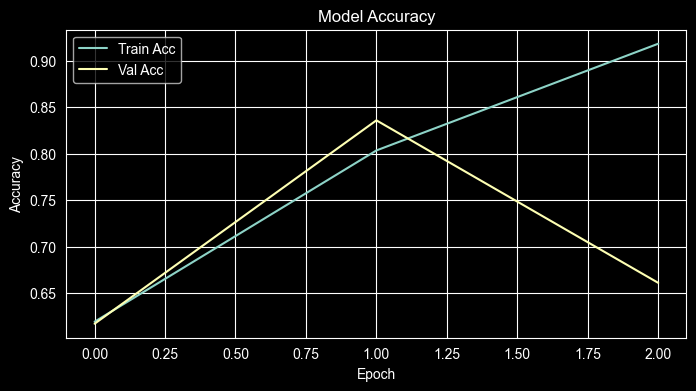

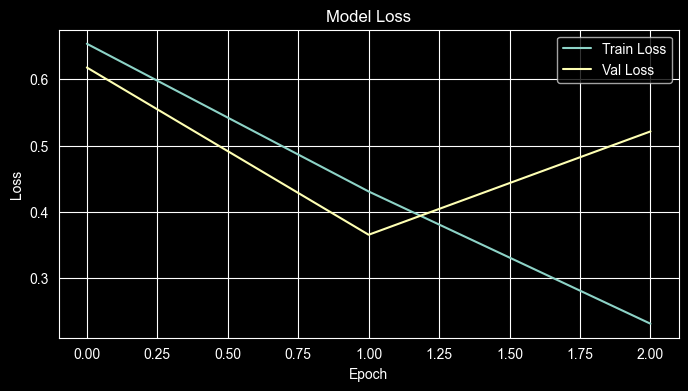

In [40]:
plt.figure(figsize=(8,4))
plt.plot(history_rnn.history['accuracy'], label='Train Acc')
plt.plot(history_rnn.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [41]:
loss, acc = model_rnn.evaluate(X_val, y_val, verbose=0)
print(f"Validation accuracy: {acc:.4f}")
print(f"Validation loss: {loss:.4f}")

Validation accuracy: 0.6609
Validation loss: 0.5213


In [42]:
print(classification_report(y_val, y_pred_rnn))
print(confusion_matrix(y_val, y_pred_rnn))

              precision    recall  f1-score   support

           0       0.56      0.89      0.69      5212
           1       0.86      0.49      0.63      7124

    accuracy                           0.66     12336
   macro avg       0.71      0.69      0.66     12336
weighted avg       0.73      0.66      0.65     12336

[[4634  578]
 [3605 3519]]


In [43]:
metrics_rnn = evaluate_model("Simple RNN", y_val, y_pred_rnn)
metrics_rnn

{'Model': 'Simple RNN',
 'Accuracy': 0.6609111543450065,
 'Precision': 0.8589211618257261,
 'Recall': 0.49396406513194835,
 'F1': 0.6272168255948668}

In [44]:
results.append(metrics_rnn)

# LSTM

In [45]:
X_train_pad = text_vec(X_train)
X_val_pad = text_vec(X_val)

In [46]:
model_lstm = Sequential([
    Embedding(input_dim=max_vocab_size, output_dim=embedding_dim),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

In [47]:
model_lstm.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

In [48]:
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=3,
    batch_size=128,
    verbose=1
)

Epoch 1/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.8809 - loss: 0.3063 - val_accuracy: 0.7617 - val_loss: 0.8950
Epoch 2/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.9142 - loss: 0.2399 - val_accuracy: 0.9617 - val_loss: 0.1443
Epoch 3/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 33s 86ms/step - accuracy: 0.9656 - loss: 0.1290 - val_accuracy: 0.8212 - val_loss: 0.4490


In [49]:
y_proba_lstm = model_lstm.predict(X_val_pad)
y_pred_lstm = (y_proba_lstm >= 0.5).astype(int).flatten()

386/386 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step


In [50]:
print(classification_report(y_val, y_pred_lstm))
print(confusion_matrix(y_val, y_pred_lstm))

              precision    recall  f1-score   support

           0       0.76      0.85      0.80      5212
           1       0.88      0.80      0.84      7124

    accuracy                           0.82     12336
   macro avg       0.82      0.82      0.82     12336
weighted avg       0.83      0.82      0.82     12336

[[4422  790]
 [1416 5708]]


In [51]:
metrics_lstm = evaluate_model("LSTM", y_val, y_pred_lstm)
metrics_lstm

{'Model': 'LSTM',
 'Accuracy': 0.8211738002594033,
 'Precision': 0.8784241305016929,
 'Recall': 0.8012352610892757,
 'F1': 0.83805608574365}

In [52]:
results.append(metrics_lstm)

# BiLSTM

In [53]:
model_bilstm = Sequential([
    Embedding(input_dim=max_vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(64)),
    Dense(1, activation="sigmoid")
])

In [54]:
model_bilstm.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

In [55]:
history_bilstm = model_bilstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=3,
    batch_size=128,
    verbose=1
)

Epoch 1/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 62s 157ms/step - accuracy: 0.9637 - loss: 0.0979 - val_accuracy: 0.9908 - val_loss: 0.0332
Epoch 2/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - accuracy: 0.9952 - loss: 0.0180 - val_accuracy: 0.9918 - val_loss: 0.0228
Epoch 3/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 53s 138ms/step - accuracy: 0.9983 - loss: 0.0061 - val_accuracy: 0.9908 - val_loss: 0.0285


In [56]:
y_proba_bilstm = model_bilstm.predict(X_val_pad)

386/386 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [57]:
y_pred_bilstm = (y_proba_bilstm >= 0.5).astype(int).flatten()

In [58]:
print(classification_report(y_val, y_pred_bilstm))
print(confusion_matrix(y_val, y_pred_bilstm))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      5212
           1       1.00      0.99      0.99      7124

    accuracy                           0.99     12336
   macro avg       0.99      0.99      0.99     12336
weighted avg       0.99      0.99      0.99     12336

[[5195   17]
 [  97 7027]]


In [59]:
metrics_bilstm = evaluate_model("Bidirectional LSTM", y_val, y_pred_bilstm)
metrics_bilstm

{'Model': 'Bidirectional LSTM',
 'Accuracy': 0.9907587548638133,
 'Precision': 0.9975865985235661,
 'Recall': 0.9863840539023021,
 'F1': 0.9919536984754376}

In [60]:
results.append(metrics_bilstm)

# BiSimple RNN

In [61]:
model_birnn = Sequential([
    Embedding(input_dim=max_vocab_size, output_dim=embedding_dim),
    Bidirectional(SimpleRNN(64)),
    Dense(1, activation="sigmoid")
])

In [62]:
model_birnn.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

In [63]:
history_birnn = model_birnn.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=3,
    batch_size=128,
    verbose=1
)


Epoch 1/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9445 - loss: 0.1352 - val_accuracy: 0.9848 - val_loss: 0.0455
Epoch 2/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9926 - loss: 0.0241 - val_accuracy: 0.9896 - val_loss: 0.0336
Epoch 3/3
386/386 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9976 - loss: 0.0091 - val_accuracy: 0.9891 - val_loss: 0.0379


In [64]:
y_proba_birnn = model_birnn.predict(X_val_pad)
y_pred_birnn = (y_proba_birnn >= 0.5).astype(int).flatten()

386/386 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [65]:
print(classification_report(y_val, y_pred_birnn))
print(confusion_matrix(y_val, y_pred_birnn))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5212
           1       0.99      0.99      0.99      7124

    accuracy                           0.99     12336
   macro avg       0.99      0.99      0.99     12336
weighted avg       0.99      0.99      0.99     12336

[[5153   59]
 [  76 7048]]


In [66]:
metrics_birnn = evaluate_model("Bidirectional RNN", y_val, y_pred_birnn)
metrics_birnn

{'Model': 'Bidirectional RNN',
 'Accuracy': 0.9890564202334631,
 'Precision': 0.9916983255944843,
 'Recall': 0.9893318360471645,
 'F1': 0.9905136673459349}

In [67]:
results.append(metrics_birnn)

# Results

In [68]:
df_results_deep = pd.DataFrame(results)
df_results_deep

,Model,Accuracy,Precision,Recall,F1
0,Simple RNN,0.660911,0.858921,0.493964,0.627217
1,LSTM,0.821174,0.878424,0.801235,0.838056
2,Bidirectional LSTM,0.990759,0.997587,0.986384,0.991954
3,Bidirectional RNN,0.989056,0.991698,0.989332,0.990514


In [69]:
df_melt_deep = df_results_deep.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

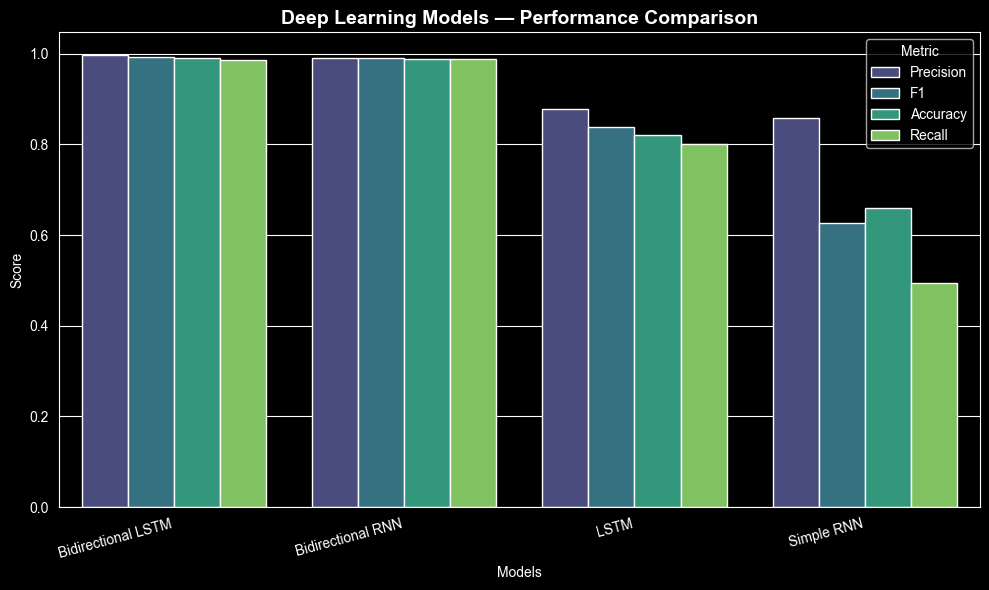

In [70]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_melt_deep.sort_values(by="Score", ascending=False),
    x="Model",
    y="Score",
    hue="Metric",
    palette="viridis"
)
plt.title("Deep Learning Models — Performance Comparison", fontsize=14, weight='bold')
plt.xticks(rotation=15, ha="right")
plt.ylabel("Score")
plt.xlabel("Models")
plt.tight_layout()
plt.show()